In [1]:
import os
import pandas as pd
import numpy as np
import plotly.express as px

import seaborn as sns
import matplotlib.pyplot as plt

/Users/phuchoangle/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/phuchoangle/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [7]:
chain_volume = pd.read_csv('/Users/phuchoangle/Desktop/concero-series-a/chain-bridge-volume/bridge-chains.csv')
bridge_volume = pd.read_csv('/Users/phuchoangle/Desktop/concero-series-a/chain-bridge-volume/bridge-and-messaging-volumes.csv')

In [5]:
chain_volume.head()

,Timestamp,Date,Ethereum,Arbitrum,Solana,BSC,Linea,Polygon,Avalanche,Optimism,...,ThunderCore,BounceBit,Dogechain,Near,Karura,Acala,Oasis,Eclipse,Gravity Bridge,X Layer.1
0,1665964800,2022-10-17,-2.848371e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1666051200,2022-10-18,-1.246014e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1666137600,2022-10-19,-1.006619e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1666224000,2022-10-20,-1.697975e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1666310400,2022-10-21,-3.372130e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
bridge_volume.head()

,Timestamp,Date,USDT0,Hyperliquid,Across,Stargate,Meson,deBridge,Mantle Bridge,IBC,...,CometBridge,Crowdswap,Shimmer Bridge,Connext,TRAIN Protocol,LayerZero,Circle CCTP,Wormhole,Hyperlane,Total
0,1665964800,2022-10-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.254599e+07
1,1666051200,2022-10-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.524086e+07
2,1666137600,2022-10-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.594582e+07
3,1666224000,2022-10-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.071904e+07
4,1666310400,2022-10-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.724354e+07


In [22]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set the style for better-looking plots
plt.style.use('ggplot')
sns.set_palette("viridis")

# File path
file_path = 'bridge-chains.csv'

# Read the CSV file
print(f"Reading data from {file_path}...")
df = pd.read_csv(file_path)

# Convert timestamp to datetime
df['datetime'] = pd.to_datetime(df['Timestamp'], unit='s')

# Filter data for 2025 and later
print("Filtering data for 2025 and later...")
df_2025 = df[df['datetime'] >= '2025-01-01'].copy()

if df_2025.empty:
    print("No data found for 2025. Please check the data range.")
else:
    print(f"Found {len(df_2025)} records for 2025 and later.")
    
    # Get all chain columns (exclude non-chain columns)
    chain_columns = [col for col in df_2025.columns if col not in ['Timestamp', 'Date', 'datetime']]
    
    # Calculate absolute volumes for each chain
    print("Calculating absolute volumes...")
    for col in chain_columns:
        df_2025[f"{col}_abs"] = df_2025[col].abs()
    
    # Calculate daily total volume across all chains
    df_2025['total_volume'] = df_2025[[f"{col}_abs" for col in chain_columns]].sum(axis=1)
    
    # Calculate total volume by chain for the entire period
    total_volumes = {}
    for col in chain_columns:
        total_volumes[col] = df_2025[f"{col}_abs"].sum()
    
    # Convert to DataFrame for better visualization
    volume_df = pd.DataFrame.from_dict(total_volumes, orient='index', columns=['Total Volume'])
    volume_df = volume_df.sort_values('Total Volume', ascending=False)

    
    # Display summary statistics
    print("\nSummary Statistics for 2025:")
    print(f"Total number of days: {len(df_2025)}")
    print(f"Average daily volume: ${df_2025['total_volume'].mean():,.2f}")
    print(f"Median daily volume: ${df_2025['total_volume'].median():,.2f}")
    print(f"Maximum daily volume: ${df_2025['total_volume'].max():,.2f}")
    print(f"Minimum daily volume: ${df_2025['total_volume'].min():,.2f}")
    
    # Show top 10 chains by volume
    print("\nTop 10 Blockchains by Total Volume in 2025:")
    print(volume_df.head(10).to_string(float_format='${:,.2f}'.format))
    
    # Save the processed data to CSV
    output_file = 'bridge_volumes_2025_processed.csv'
    df_2025.to_csv(output_file, index=False)
    print(f"\nProcessed data saved to {output_file}")

Reading data from bridge-chains.csv...
Filtering data for 2025 and later...
Found 190 records for 2025 and later.
Calculating absolute volumes...

Summary Statistics for 2025:
Total number of days: 190
Average daily volume: $186,312,717.09
Median daily volume: $135,446,852.46
Maximum daily volume: $1,958,076,795.84
Minimum daily volume: $25,465,434.64

Top 10 Blockchains by Total Volume in 2025:
                Total Volume
Ethereum  $16,631,649,215.34
Arbitrum   $8,100,738,966.17
Avalanche  $2,471,136,119.79
BSC        $2,060,814,989.57
Solana     $1,908,501,458.39
Sei          $762,257,877.04
Optimism     $745,377,983.24
Polygon      $504,603,093.38
Sui          $292,486,348.40
Sonic        $254,868,425.58

Processed data saved to bridge_volumes_2025_processed.csv


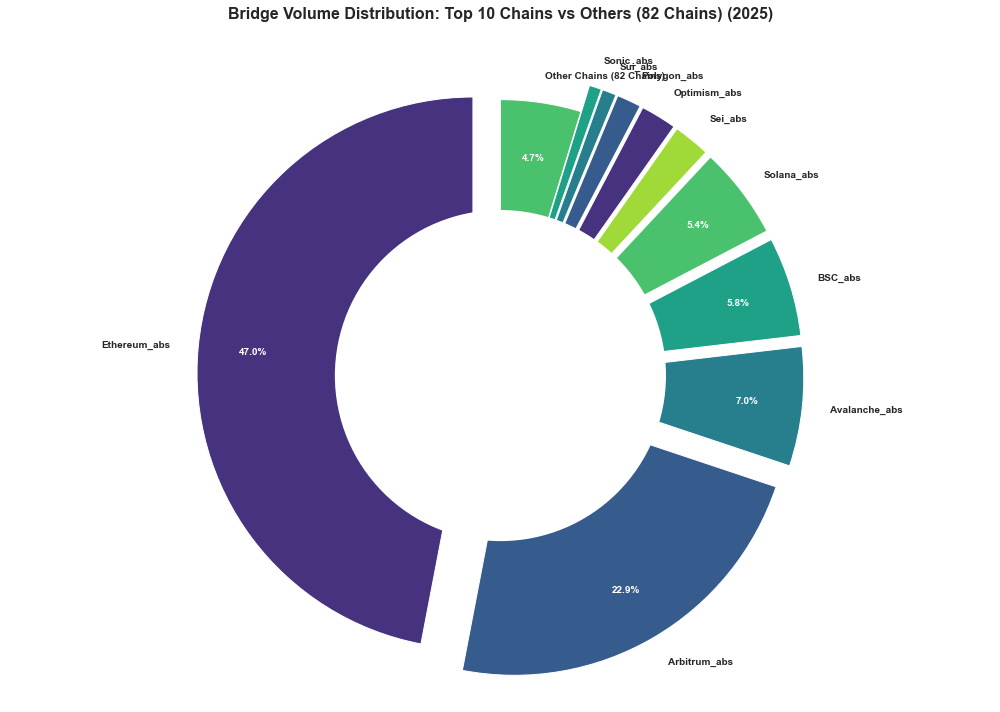

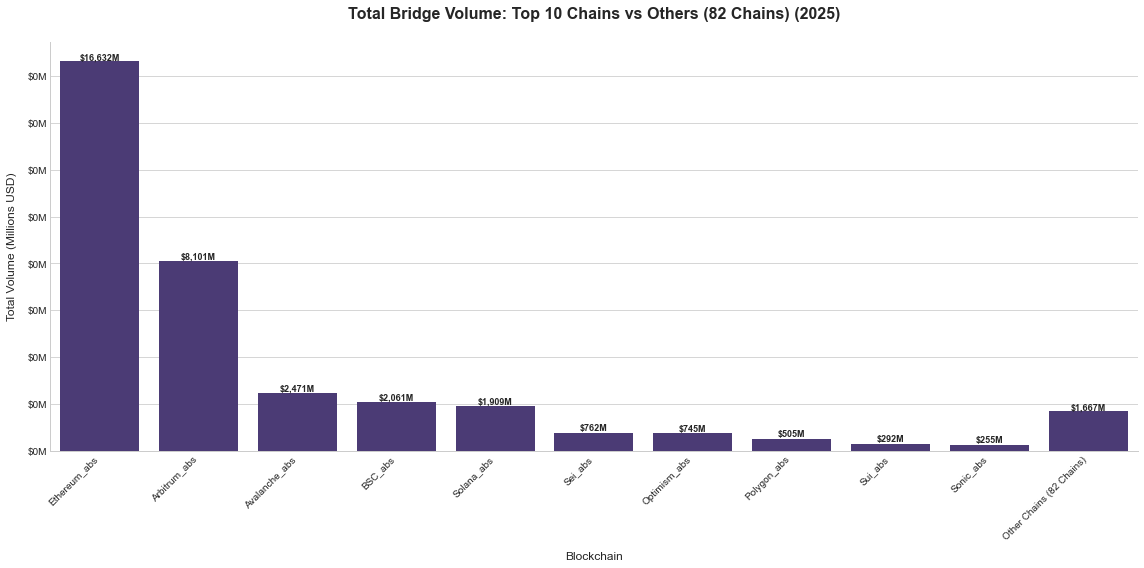

Summary Statistics (in millions USD):
                Top 10 Chains   Other Chains    Total          
--------------------------------------------------
Daily Avg:      $178M           $9M             $186M          
Monthly Avg:    $4,819M         $238M           $5,057M        
Quarterly Avg:  $11,244M        $556M           $11,800M       

Percentage of Total Volume:
                Top 10 Chains   Other Chains   
--------------------------------------------------
Daily:          95.3%           4.7%
Monthly:        95.3%           4.7%
Quarterly:      95.3%           4.7%
Bridge Volume Distribution by Chain
                   Chain Volume (USD) Percentage
            Ethereum_abs      $16.63B     46.98%
            Arbitrum_abs       $8.10B     22.88%
           Avalanche_abs       $2.47B      6.98%
                 BSC_abs       $2.06B      5.82%
              Solana_abs       $1.91B      5.39%
                 Sei_abs       $0.76B      2.15%
            Optimism_abs       $0.75B

/var/folders/7j/4shxr2bn0wq270wnn4zcvyxr0000gn/T/ipykernel_14149/3010140911.py:162: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_top10 = df['top_10_volume'].resample('M').sum().mean()
/var/folders/7j/4shxr2bn0wq270wnn4zcvyxr0000gn/T/ipykernel_14149/3010140911.py:163: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_other = df['other_volume'].resample('M').sum().mean()
/var/folders/7j/4shxr2bn0wq270wnn4zcvyxr0000gn/T/ipykernel_14149/3010140911.py:166: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_avg_top10 = df['top_10_volume'].resample('Q').sum().mean()
/var/folders/7j/4shxr2bn0wq270wnn4zcvyxr0000gn/T/ipykernel_14149/3010140911.py:167: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_avg_other = df['other_volume'].resample('Q').sum

<Figure size 1152x576 with 0 Axes>

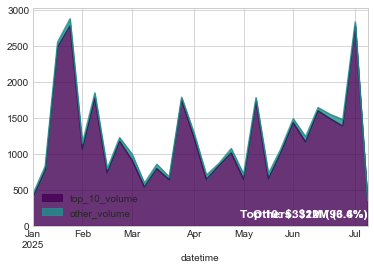

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import MaxNLocator

# Set the style for better-looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Function to format numbers in millions
def millions(x, pos):
    return f'${x/1e6:.0f}M'

# Load the processed data
df = pd.read_csv('bridge_volumes_2025_processed.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# Get absolute volume columns
volume_cols = [col for col in df.columns if col.endswith('_abs')]

# Calculate total volume for each chain
total_volumes = df[volume_cols].sum().sort_values(ascending=False)

# Get top 10 chains and sum the rest
top_10_chains = total_volumes.head(10)
other_chains = total_volumes[10:].sum()

# Create a new series for the pie chart
pie_data = pd.concat([top_10_chains, pd.Series({'Other Chains (82 Chains)': other_chains})])

# 1. Improved Pie Chart
plt.figure(figsize=(14, 10))
# Explode the slices for better visibility
explode = [0.1] * len(pie_data)
explode[-1] = 0  # Don't explode the "Other" slice

# Create pie chart with better formatting
patches, texts, autotexts = plt.pie(
    pie_data, 
    labels=pie_data.index, 
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle=90,
    explode=explode,
    textprops={'fontsize': 10, 'weight': 'bold'},
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

# Make percentages larger and white for better visibility
for text in autotexts:
    text.set_color('white')
    text.set_size(10)
    text.set_weight('bold')

# Add a white circle in the middle to make it a donut chart
centre_circle = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Bridge Volume Distribution: Top 10 Chains vs Others (82 Chains) (2025)\n', 
          fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.savefig('volume_distribution_pie_improved.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 2. Improved Bar Chart
plt.figure(figsize=(16, 8))
ax = sns.barplot(x=pie_data.index, y=pie_data.values / 1e6)

# Add value labels on top of bars
for i, v in enumerate(pie_data.values / 1e6):
    ax.text(i, v + 5, f'${v:,.0f}M', 
            ha='center', 
            va='bottom',
            fontsize=9,
            fontweight='bold')

plt.title('Total Bridge Volume: Top 10 Chains vs Others (82 Chains) (2025)\n', 
          fontsize=16, fontweight='bold')
plt.ylabel('Total Volume (Millions USD)', fontsize=12, labelpad=10)
plt.xlabel('Blockchain', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Format y-axis to show in millions
formatter = FuncFormatter(millions)
ax.yaxis.set_major_formatter(formatter)

# Remove top and right spines
sns.despine()

plt.tight_layout()
plt.savefig('volume_comparison_bar_improved.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 3. Stacked Area Chart for Weekly Volume
# Prepare data for the stacked area chart
df.set_index('datetime', inplace=True)
df['top_10_volume'] = df[top_10_chains.index].sum(axis=1)
df['other_volume'] = df[volume_cols].sum(axis=1) - df['top_10_volume']

# Resample to weekly
weekly_df = df[['top_10_volume', 'other_volume']].resample('W').sum()

# Convert to millions
weekly_df = weekly_df / 1e6

# Create the stacked area chart
plt.figure(figsize=(16, 8))

# Create the stacked area plot
ax = weekly_df.plot.area(
    stacked=True,
    alpha=0.8,
    color=['#440154', '#21918c']  # Using viridis colors
)

# Add value labels for the most recent week
last_week = weekly_df.iloc[-1]
total = last_week.sum()
ax.text(
    weekly_df.index[-1], 
    total/2, 
    f'Top 10: ${last_week["top_10_volume"]:,.0f}M ({last_week["top_10_volume"]/total*100:.1f}%)',
    ha='right',
    va='center',
    fontsize=12,
    fontweight='bold',
    color='white'
)

ax.text(
    weekly_df.index[-1], 
    last_week["top_10_volume"]/2, 
    f'Others: ${last_week["other_volume"]:,.0f}M ({last_week["other_volume"]/total*100:.1f}%)',
    ha='right',
    va='center',
    fontsize=12,
    fontweight='bold',
    color='white'
)

# Print summary statistics
print("Summary Statistics (in millions USD):")
print("="*50)
print(f"{'':<15} {'Top 10 Chains':<15} {'Other Chains':<15} {'Total':<15}")
print("-"*50)

# Function to format numbers
def format_millions(x):
    return f"${x/1e6:,.0f}M"

# Calculate and print statistics
daily_avg_top10 = df['top_10_volume'].mean()
daily_avg_other = df['other_volume'].mean()
daily_total = daily_avg_top10 + daily_avg_other

monthly_avg_top10 = df['top_10_volume'].resample('M').sum().mean()
monthly_avg_other = df['other_volume'].resample('M').sum().mean()
monthly_total = monthly_avg_top10 + monthly_avg_other

quarterly_avg_top10 = df['top_10_volume'].resample('Q').sum().mean()
quarterly_avg_other = df['other_volume'].resample('Q').sum().mean()
quarterly_total = quarterly_avg_top10 + quarterly_avg_other

print(f"{'Daily Avg:':<15} {format_millions(daily_avg_top10):<15} {format_millions(daily_avg_other):<15} {format_millions(daily_total):<15}")
print(f"{'Monthly Avg:':<15} {format_millions(monthly_avg_top10):<15} {format_millions(monthly_avg_other):<15} {format_millions(monthly_total):<15}")
print(f"{'Quarterly Avg:':<15} {format_millions(quarterly_avg_top10):<15} {format_millions(quarterly_avg_other):<15} {format_millions(quarterly_total):<15}")

# Calculate percentages
print("\nPercentage of Total Volume:")
print("="*50)
print(f"{'':<15} {'Top 10 Chains':<15} {'Other Chains':<15}")
print("-"*50)
print(f"{'Daily:':<15} {daily_avg_top10/daily_total*100:.1f}%{'':<10} {daily_avg_other/daily_total*100:.1f}%")
print(f"{'Monthly:':<15} {monthly_avg_top10/monthly_total*100:.1f}%{'':<10} {monthly_avg_other/monthly_total*100:.1f}%")
print(f"{'Quarterly:':<15} {quarterly_avg_top10/quarterly_total*100:.1f}%{'':<10} {quarterly_avg_other/quarterly_total*100:.1f}%")

# Calculate percentages for the pie chart data
pie_percentages = (pie_data / pie_data.sum()) * 100

# Create a DataFrame for better formatting
percentage_table = pd.DataFrame({
    'Chain': pie_percentages.index,
    'Volume (USD)': pie_data.values,
    'Percentage': pie_percentages.values
})

# Format the numbers for display
display_table = percentage_table.copy()
display_table['Volume (USD)'] = display_table['Volume (USD)'].apply(lambda x: f"${x/1e9:,.2f}B")
display_table['Percentage'] = display_table['Percentage'].apply(lambda x: f"{x:.2f}%")

# Display the table
print("Bridge Volume Distribution by Chain")
print("=" * 60)
print(display_table.to_string(index=False))
print("=" * 60)

# You can also save this to a CSV if needed
display_table.to_csv('bridge_volume_distribution.csv', index=False)

# Save the formatted display table (with $ and % symbols)
display_table.to_csv('bridge_volume_distribution_formatted.csv', index=False)

# Save the raw data (numbers without formatting) for further analysis
percentage_table.to_csv('bridge_volume_distribution_raw.csv', index=False)

print("Data has been saved to 'bridge_volume_distribution_formatted.csv' and 'bridge_volume_distribution_raw.csv'")

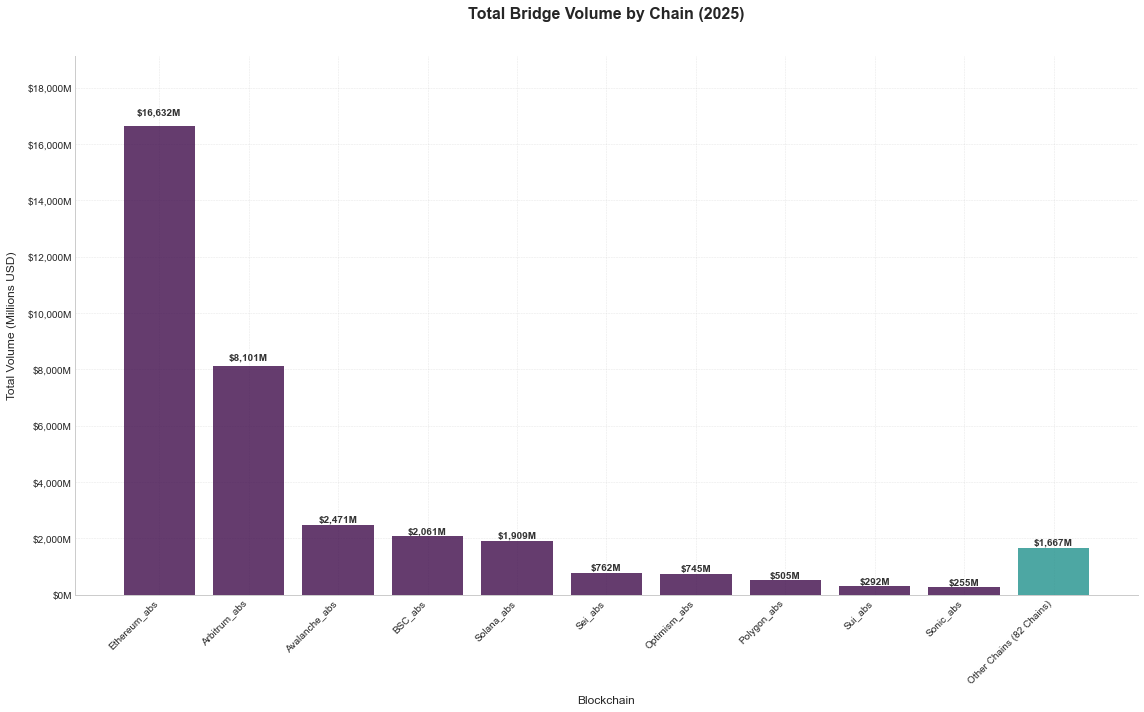

<Figure size 1152x576 with 0 Axes>

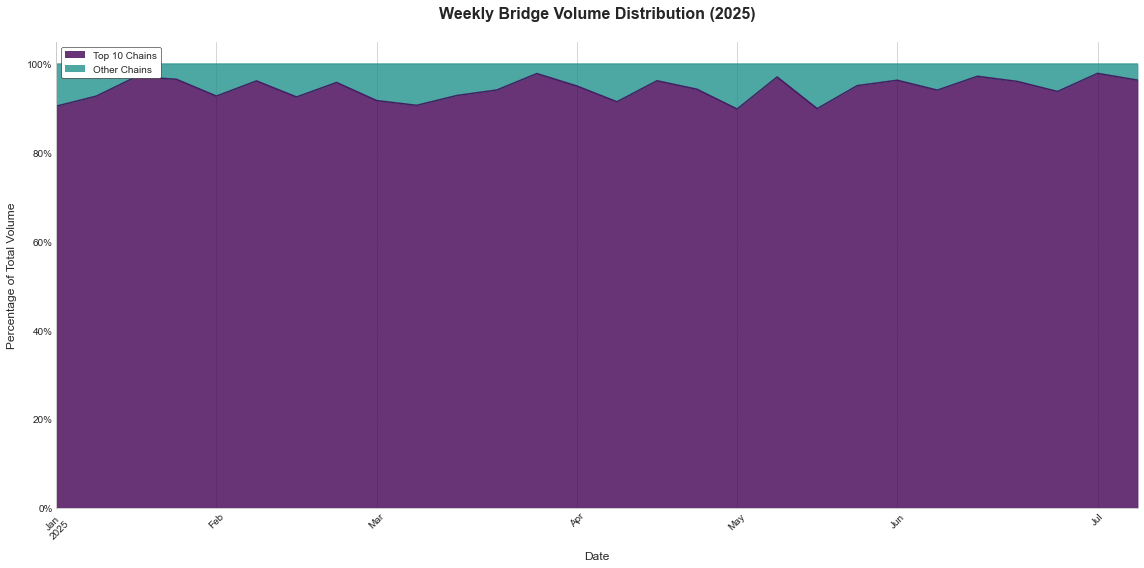

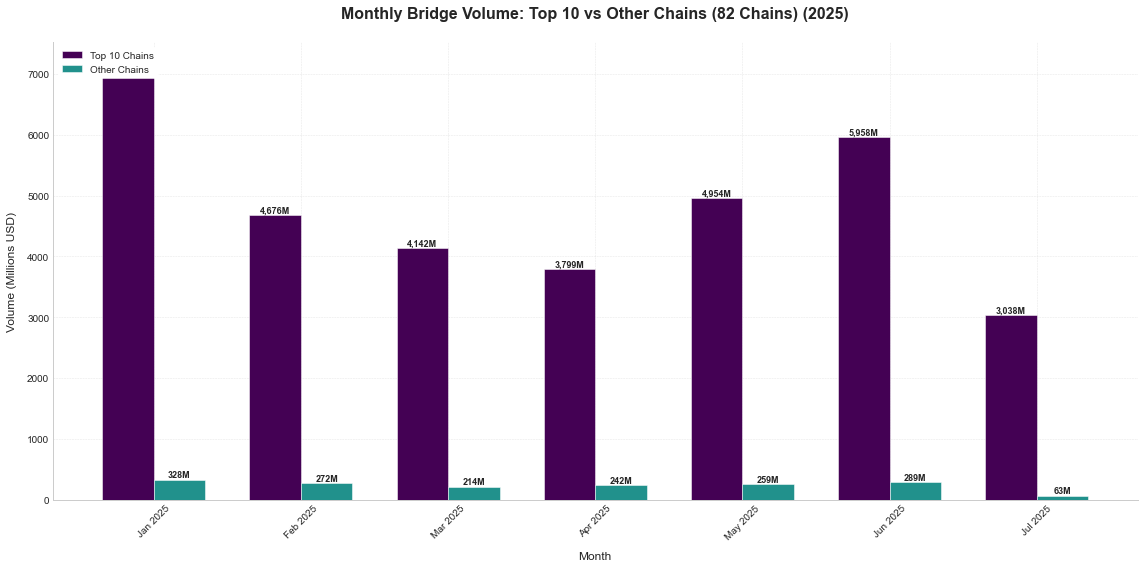

Summary Statistics (in millions USD):
                Top 10 Chains        Other Chains         Total                % Other Chains 
----------------------------------------------------------------------
Jan 2025        $7,166M              $328M                $7,494M              4.4%
Feb 2025        $4,676M              $272M                $4,948M              5.5%
Mar 2025        $4,142M              $214M                $4,356M              4.9%
Apr 2025        $3,799M              $242M                $4,041M              6.0%
May 2025        $4,954M              $259M                $5,213M              5.0%
Jun 2025        $5,958M              $289M                $6,247M              4.6%
Jul 2025        $3,038M              $63M                 $3,101M              2.0%
----------------------------------------------------------------------
TOTAL           $33,732M             $1,667M              $35,399M             4.7%


In [36]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter
from matplotlib.ticker import MaxNLocator

# Set the style for better-looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Function to format numbers in millions
def millions(x, pos):
    return f'${x:,.0f}M'

# Load the processed data
df = pd.read_csv('bridge_volumes_2025_processed.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# Get absolute volume columns
volume_cols = [col for col in df.columns if col.endswith('_abs')]

# Calculate total volume for each chain
total_volumes = df[volume_cols].sum().sort_values(ascending=False)

# Get top 10 chains and sum the rest
top_10_chains = total_volumes.head(10)
other_chains = total_volumes[10:].sum()

# 1. Improved Bar Chart with visible Y-axis
plt.figure(figsize=(16, 10))
ax = sns.barplot(x=top_10_chains.index, y=top_10_chains.values / 1e6, 
                color='#440154', alpha=0.8)

# Add value labels on top of bars
for i, v in enumerate(top_10_chains.values / 1e6):
    ax.text(i, v * 1.02, f'${v:,.0f}M', 
            ha='center', 
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='#333')

# Add the "Other" bar
other_idx = len(top_10_chains)
ax.bar(other_idx, other_chains / 1e6, color='#21918c', alpha=0.8)
ax.text(other_idx, (other_chains / 1e6) * 1.02, f'${other_chains/1e6:,.0f}M',
        ha='center', 
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#333')

# Set x-tick labels
x_labels = list(top_10_chains.index) + ['Other Chains (82 Chains)']
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)

# Format y-axis with proper ticks
y_max = max(top_10_chains.max(), other_chains) / 1e6
ax.set_ylim(0, y_max * 1.15)  # Add 15% padding
ax.yaxis.set_major_formatter(FuncFormatter(millions))
ax.yaxis.set_major_locator(MaxNLocator(10))  # Ensure we have enough y-ticks

# Add grid lines
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

plt.title('Total Bridge Volume by Chain (2025)\n', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Total Volume (Millions USD)', fontsize=12, labelpad=10)
plt.xlabel('Blockchain', fontsize=12, labelpad=10)

# Remove top and right spines
sns.despine()

plt.tight_layout()
plt.savefig('volume_comparison_bar_fixed.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 2. Stacked Area Chart (Percentage)
df.set_index('datetime', inplace=True)
df['top_10_volume'] = df[top_10_chains.index].sum(axis=1)
df['other_volume'] = df[volume_cols].sum(axis=1) - df['top_10_volume']

# Resample to weekly and calculate percentages
weekly_df = df[['top_10_volume', 'other_volume']].resample('W').sum()
weekly_total = weekly_df.sum(axis=1)
weekly_pct = weekly_df.div(weekly_total, axis=0) * 100

# Create the stacked area chart
plt.figure(figsize=(16, 8))

# Define colors
colors = ['#440154', '#21918c']  # Dark purple and teal from viridis

# Create the stacked area plot with explicit color mapping
ax = weekly_pct.plot.area(
    stacked=True,
    alpha=0.8,
    color=colors,
    figsize=(16, 8)
)

# Add percentage labels for the most recent week
last_week = weekly_pct.iloc[-1]

# Format the plot
plt.title('Weekly Bridge Volume Distribution (2025)\n', 
          fontsize=16, fontweight='bold')
plt.ylabel('Percentage of Total Volume', fontsize=12, labelpad=10)
plt.xlabel('Date', fontsize=12, labelpad=10)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Format y-axis as percentage
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Add grid
plt.grid(True, alpha=0.3, which='both', axis='y')

# Create custom legend with matching colors
legend_elements = [
    plt.Rectangle((0,0), 1, 1, fc=colors[0], alpha=0.8, label='Top 10 Chains'),
    plt.Rectangle((0,0), 1, 1, fc=colors[1], alpha=0.8, label='Other Chains')
]

# Add legend with custom elements
plt.legend(
    handles=legend_elements,
    loc='upper left',
    frameon=True,
    framealpha=1,
    edgecolor='black'
)

# Remove top and right spines
sns.despine()

plt.tight_layout()
plt.savefig('weekly_volume_percentage.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 3. Monthly Volume Bar Chart
# Resample to monthly
monthly_df = df[['top_10_volume', 'other_volume']].resample('M').sum() / 1e6  # Convert to millions

# Create a new figure
plt.figure(figsize=(16, 8))

# Set width of bars
bar_width = 0.35

# Set positions of bars on X axis
r1 = np.arange(len(monthly_df))
r2 = [x + bar_width for x in r1]

# Create bars
plt.bar(r1, monthly_df['top_10_volume'], color='#440154', width=bar_width, edgecolor='white', label='Top 10 Chains')
plt.bar(r2, monthly_df['other_volume'], color='#21918c', width=bar_width, edgecolor='white', label='Other Chains')

# Add value labels on top of bars
def add_value_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{height:,.0f}M',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold')

add_value_labels(plt.gca().containers[0], plt.gca())
add_value_labels(plt.gca().containers[1], plt.gca())

# Add xticks on the middle of the group bars
plt.xlabel('Month', fontsize=12, labelpad=10)
plt.ylabel('Volume (Millions USD)', fontsize=12, labelpad=10)
plt.title('Monthly Bridge Volume: Top 10 vs Other Chains (82 Chains) (2025)\n', 
          fontsize=16, fontweight='bold')

# Format x-axis
plt.xticks([r + bar_width/2 for r in range(len(monthly_df))], 
           monthly_df.index.strftime('%b %Y'), 
           rotation=45)

# Add grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

# Add legend
plt.legend(loc='upper left', frameon=True, framealpha=1, edgecolor='white')

# Remove top and right spines
sns.despine()

plt.tight_layout()
plt.savefig('monthly_volume_comparison_bridge.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Print summary statistics
print("Summary Statistics (in millions USD):")
print("="*70)
print(f"{'':<15} {'Top 10 Chains':<20} {'Other Chains':<20} {'Total':<20} {'% Other Chains':<15}")
print("-"*70)

# Calculate and print statistics
def format_millions(x):
    return f"${x:,.0f}M"

monthly_totals = monthly_df.sum(axis=1)
monthly_other_pct = (monthly_df['other_volume'] / monthly_totals * 100).round(1)

for idx, (date, row) in enumerate(monthly_df.iterrows()):
    total = row.sum()
    print(f"{date.strftime('%b %Y'):<15} {format_millions(row['top_10_volume']):<20} {format_millions(row['other_volume']):<20} {format_millions(total):<20} {monthly_other_pct.iloc[idx]}%")

# Add overall totals
print("-"*70)
total_top10 = monthly_df['top_10_volume'].sum()
total_other = monthly_df['other_volume'].sum()
grand_total = total_top10 + total_other
print(f"{'TOTAL':<15} {format_millions(total_top10):<20} {format_millions(total_other):<20} {format_millions(grand_total):<20} {(total_other/grand_total*100):.1f}%")

In [17]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('bridge-and-messaging-volumes.csv')

# Convert the 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Filter data from 2025 onwards
df_2025 = df[df['Date'] >= '2025-01-01'].copy()

# Select only the required columns
selected_columns = ['Timestamp', 'Date', 'LayerZero', 'Circle CCTP', 'Wormhole', 'Hyperlane']
result_df = df_2025[selected_columns]

# Sort by date in ascending order
result_df = result_df.sort_values('Date')

# Display the result
print(f"Found {len(result_df)} records from 2025 onwards")
print("\nFirst few rows of the filtered data:")
print(result_df.head())

# Save to a new CSV file
output_file = 'messaging_volumes_2025.csv'
result_df.to_csv(output_file, index=False)
print(f"\nData saved to {output_file}")

# Display summary statistics
print("\nSummary Statistics (2025):")
print("="*70)
print(result_df[['LayerZero', 'Circle CCTP', 'Wormhole', 'Hyperlane']].describe().applymap(lambda x: f"${x:,.2f}" if isinstance(x, (int, float)) else x))

Found 190 records from 2025 onwards

First few rows of the filtered data:
      Timestamp       Date  LayerZero   Circle CCTP      Wormhole  Hyperlane
807  1735689600 2025-01-01        NaN  8.512961e+07  4.991630e+07        NaN
808  1735776000 2025-01-02        NaN  1.160577e+08  1.150073e+08        NaN
809  1735862400 2025-01-03        NaN  1.226561e+08  7.435807e+07        NaN
810  1735948800 2025-01-04        NaN  8.594310e+07  5.296580e+07        NaN
811  1736035200 2025-01-05        NaN  5.929111e+07  5.350242e+07        NaN

Data saved to messaging_volumes_2025.csv

Summary Statistics (2025):
             LayerZero      Circle CCTP           Wormhole        Hyperlane
count          $158.00          $190.00            $190.00          $111.00
mean   $174,307,019.17  $105,359,541.78     $51,037,174.72   $14,801,801.88
std    $107,322,346.01   $66,906,715.58     $79,678,148.58   $26,314,934.07
min          $3,101.60   $24,749,014.09      $4,110,667.20       $69,586.23
25%    $116,99

/var/folders/7j/4shxr2bn0wq270wnn4zcvyxr0000gn/T/ipykernel_23515/4049192718.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(result_df[['LayerZero', 'Circle CCTP', 'Wormhole', 'Hyperlane']].describe().applymap(lambda x: f"${x:,.2f}" if isinstance(x, (int, float)) else x))


In [1]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('bridge-and-messaging-volumes.csv')

# Convert the 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Filter data from October 2024 to June 2025
start_date = '2024-10-01'
end_date = '2025-06-30'
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

# Select only the required columns
selected_columns = ['Timestamp', 'Date', 'LayerZero', 'Circle CCTP', 'Wormhole', 'Hyperlane']
result_df = df_filtered[selected_columns]

# Set Date as index for resampling
monthly_volume = result_df.set_index('Date').resample('M').sum()

# Format the index to show Year-Month
monthly_volume.index = monthly_volume.index.strftime('%Y-%m')

# Remove the 'Timestamp' column as it's not needed in the monthly summary
monthly_volume = monthly_volume.drop(columns=['Timestamp'])

# Display the monthly volumes
print("Monthly Volumes (October 2024 - June 2025):")
print("="*70)
print(monthly_volume)

# Calculate and display total volume for the period
print("\nTotal Volume (October 2024 - June 2025):")
print("="*70)
total_volume = monthly_volume.sum().to_frame('Total Volume')
print(total_volume)

# Save to a new CSV file
output_file = 'monthly_messaging_volumes_2024_2025.csv'
monthly_volume.to_csv(output_file)
print(f"\nMonthly volume data saved to {output_file}")

/Users/phuchoangle/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/phuchoangle/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


Monthly Volumes (October 2024 - June 2025):
            LayerZero   Circle CCTP      Wormhole     Hyperlane
Date                                                           
2024-10  0.000000e+00  1.438498e+09  0.000000e+00  0.000000e+00
2024-11  0.000000e+00  2.790280e+09  9.687208e+08  0.000000e+00
2024-12  0.000000e+00  3.737023e+09  2.947286e+09  0.000000e+00
2025-01  0.000000e+00  4.474709e+09  2.815440e+09  0.000000e+00
2025-02  3.128758e+09  2.904512e+09  1.524580e+09  0.000000e+00
2025-03  5.114950e+09  2.366811e+09  1.053968e+09  1.041986e+08
2025-04  5.556944e+09  3.101435e+09  1.109438e+09  2.206565e+08
2025-05  7.310412e+09  3.466759e+09  1.109648e+09  4.076040e+08
2025-06  5.262212e+09  2.977005e+09  9.036837e+08  8.635336e+08

Total Volume (October 2024 - June 2025):
             Total Volume
LayerZero    2.637328e+10
Circle CCTP  2.725703e+10
Wormhole     1.243276e+10
Hyperlane    1.595993e+09

Monthly volume data saved to monthly_messaging_volumes_2024_2025.csv


/var/folders/7j/4shxr2bn0wq270wnn4zcvyxr0000gn/T/ipykernel_14369/1187172280.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = result_df.set_index('Date').resample('M').sum()


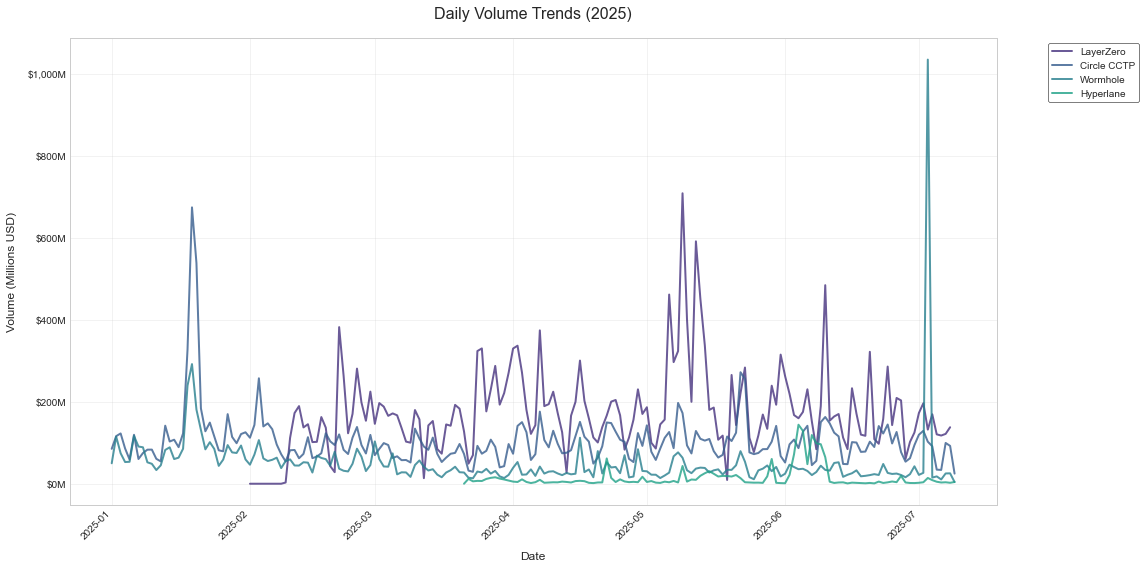

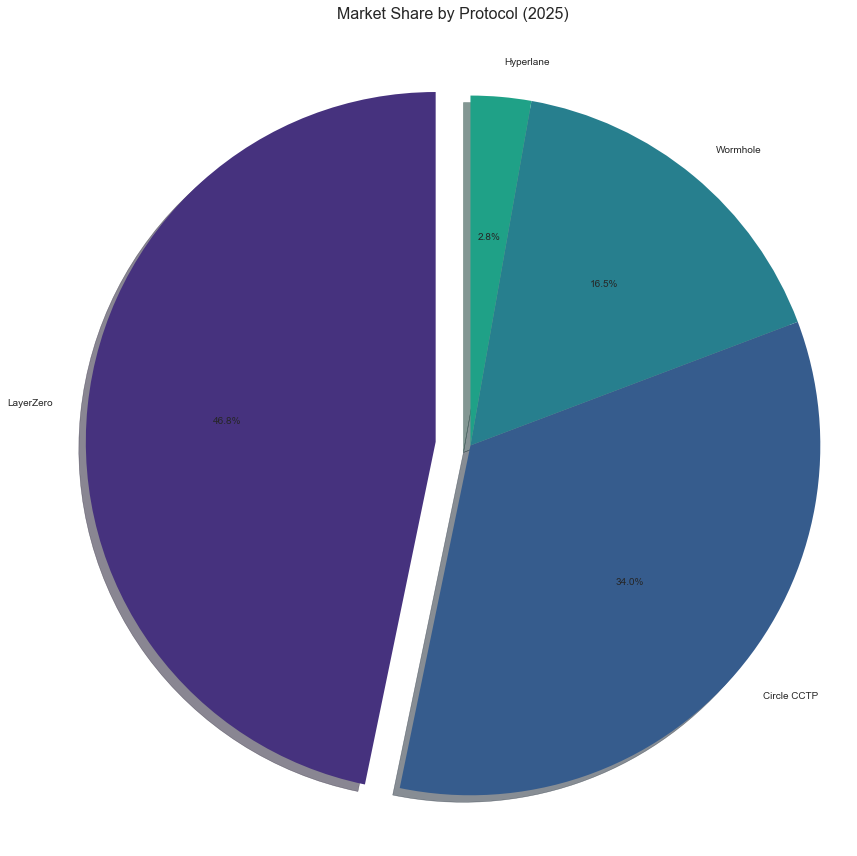

<Figure size 1008x504 with 0 Axes>

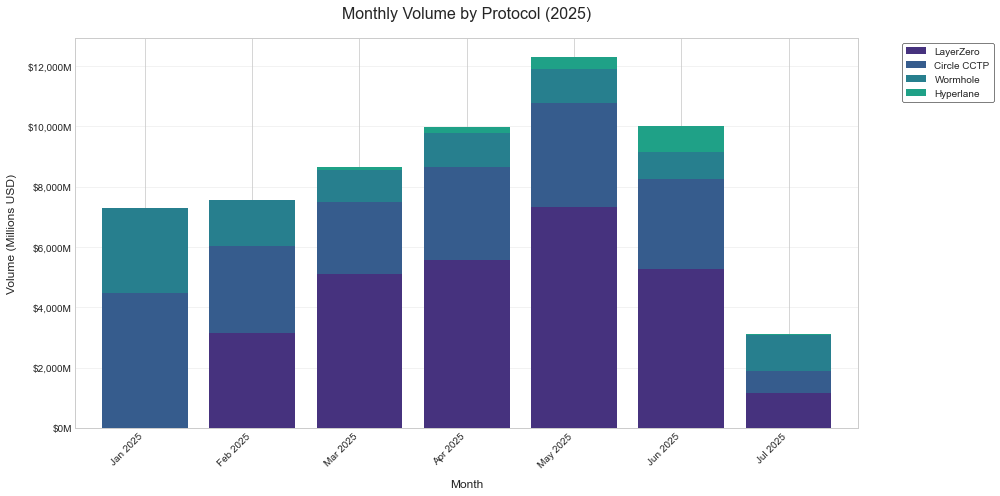

Analysis complete! All plots have been saved as PNG files.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Function to format numbers in millions
def millions(x, pos):
    return f'${x/1e6:,.0f}M'

# Load and prepare the data
df = pd.read_csv('bridge-and-messaging-volumes.csv')
df['Date'] = pd.to_datetime(df['Date'])
df_2025 = df[df['Date'] >= '2025-01-01'].copy()
protocols = ['LayerZero', 'Circle CCTP', 'Wormhole', 'Hyperlane']
result_df = df_2025[['Date'] + protocols].sort_values('Date').reset_index(drop=True)

# 1. Time Series Analysis
plt.figure(figsize=(16, 8))
for protocol in protocols:
    plt.plot(result_df['Date'], result_df[protocol], label=protocol, alpha=0.8, linewidth=2)

# Format y-axis in millions
formatter = FuncFormatter(millions)
plt.gca().yaxis.set_major_formatter(formatter)

# Add labels and title
plt.title('Daily Volume Trends (2025)', fontsize=16, pad=20)
plt.ylabel('Volume (Millions USD)', fontsize=12, labelpad=10)
plt.xlabel('Date', fontsize=12, labelpad=10)

# Add grid and legend
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, framealpha=1, edgecolor='black')

# Rotate x-ticks and adjust layout
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the figure
plt.savefig('daily_volume_trends.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 2. Market Share Pie Chart
plt.figure(figsize=(12, 12))
total_volumes = result_df[protocols].sum()
explode = (0.1, 0, 0, 0)  # explode the 1st slice
plt.pie(total_volumes, labels=total_volumes.index, 
        autopct='%1.1f%%', startangle=90, 
        explode=explode, shadow=True)
plt.title('Market Share by Protocol (2025)', fontsize=16, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.savefig('market_share_pie.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Monthly Volume Comparison
plt.figure(figsize=(14, 7))
monthly = result_df.set_index('Date').resample('M').sum()

# Create the stacked bar plot
ax = monthly.plot(kind='bar', stacked=True, figsize=(14, 7), width=0.8)

# Format y-axis in millions
ax.yaxis.set_major_formatter(FuncFormatter(millions))

# Format x-axis with month-year labels
monthly_dates = monthly.index.strftime('%b %Y')
ax.set_xticklabels(monthly_dates, rotation=45, ha='right')

# Add labels and title
plt.title('Monthly Volume by Protocol (2025)', fontsize=16, pad=20)
plt.ylabel('Volume (Millions USD)', fontsize=12, labelpad=10)
plt.xlabel('Month', fontsize=12, labelpad=10)

# Add grid and legend
plt.grid(axis='y', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, framealpha=1, edgecolor='black')

# Adjust layout and save
plt.tight_layout()
plt.savefig('monthly_volume_comparison_messaging.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Analysis complete! All plots have been saved as PNG files.")

Estimated Fees by Basis Points (bps) and Chain Category


,Month,Top 10 (1bps),Other (1bps),Total (1bps),Top 10 (2bps),Other (2bps),Total (2bps),Top 10 (3bps),Other (3bps),Total (3bps),Top 10 (5bps),Other (5bps),Total (5bps),Top 10 (10bps),Other (10bps),Total (10bps)
0,Jan 2025,$0.72M,$0.03M,$0.75M,$1.43M,$0.07M,$1.50M,$2.15M,$0.10M,$2.25M,$3.58M,$0.16M,$3.75M,$7.17M,$0.33M,$7.49M
1,Feb 2025,$0.47M,$0.03M,$0.49M,$0.94M,$0.05M,$0.99M,$1.40M,$0.08M,$1.48M,$2.34M,$0.14M,$2.47M,$4.68M,$0.27M,$4.95M
2,Mar 2025,$0.41M,$0.02M,$0.44M,$0.83M,$0.04M,$0.87M,$1.24M,$0.06M,$1.31M,$2.07M,$0.11M,$2.18M,$4.14M,$0.21M,$4.36M
3,Apr 2025,$0.38M,$0.02M,$0.40M,$0.76M,$0.05M,$0.81M,$1.14M,$0.07M,$1.21M,$1.90M,$0.12M,$2.02M,$3.80M,$0.24M,$4.04M
4,May 2025,$0.50M,$0.03M,$0.52M,$0.99M,$0.05M,$1.04M,$1.49M,$0.08M,$1.56M,$2.48M,$0.13M,$2.61M,$4.95M,$0.26M,$5.21M
5,Jun 2025,$0.60M,$0.03M,$0.62M,$1.19M,$0.06M,$1.25M,$1.79M,$0.09M,$1.87M,$2.98M,$0.14M,$3.12M,$5.96M,$0.29M,$6.25M
6,Jul 2025,$0.30M,$0.01M,$0.31M,$0.61M,$0.01M,$0.62M,$0.91M,$0.02M,$0.93M,$1.52M,$0.03M,$1.55M,$3.04M,$0.06M,$3.10M
7,Annual Total,$3.37M,$0.17M,$3.54M,$6.75M,$0.33M,$7.08M,$10.12M,$0.50M,$10.62M,$16.87M,$0.83M,$17.70M,$33.73M,$1.67M,$35.40M



Annual Fee Summary by Fee Rate


,Fee Rate (bps),Top 10 Chains,Other Chains,Total Fees,Top 10 %,Other %
0,1,$3.37M,$0.17M,$3.54M,95.3%,4.7%
1,2,$6.75M,$0.33M,$7.08M,95.3%,4.7%
2,3,$10.12M,$0.50M,$10.62M,95.3%,4.7%
3,5,$16.87M,$0.83M,$17.70M,95.3%,4.7%
4,10,$33.73M,$1.67M,$35.40M,95.3%,4.7%


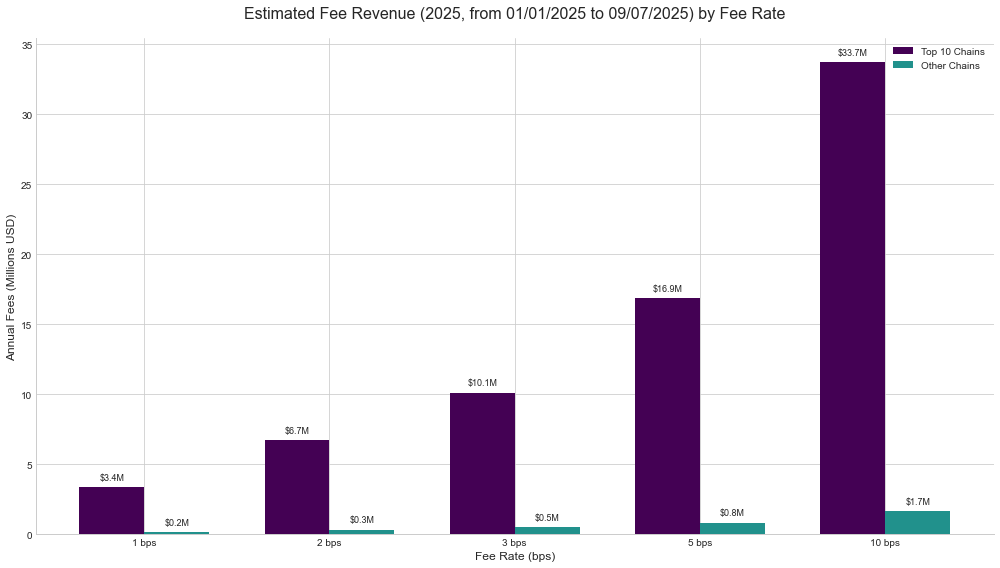

In [39]:
# Define the basis points we want to calculate fees for
bps_rates = [1, 2, 3, 5, 10]

# Create a function to calculate fees
def calculate_fees(volume_millions, bps):
    # Convert from millions to actual value, then calculate fee
    return (volume_millions * 1_000_000) * (bps / 10_000)

# Create a list to store the results
fee_results = []

# Calculate fees for each month
for idx, (date, row) in enumerate(monthly_df.iterrows()):
    month_data = {'Month': date.strftime('%b %Y')}
    total_volume = row['top_10_volume'] + row['other_volume']
    
    for bps in bps_rates:
        # Calculate fees in millions USD
        fees_top10 = calculate_fees(row['top_10_volume'], bps) / 1_000_000
        fees_other = calculate_fees(row['other_volume'], bps) / 1_000_000
        fees_total = fees_top10 + fees_other
        
        month_data[f'Top 10 ({bps}bps)'] = f'${fees_top10:,.2f}M'
        month_data[f'Other ({bps}bps)'] = f'${fees_other:,.2f}M'
        month_data[f'Total ({bps}bps)'] = f'${fees_total:,.2f}M'
    
    fee_results.append(month_data)

# Create a DataFrame for better display
import pandas as pd
fee_df = pd.DataFrame(fee_results)

# Calculate annual totals
annual_totals = {
    'Month': 'Annual Total',
}

for bps in bps_rates:
    total_top10 = sum(calculate_fees(monthly_df['top_10_volume'], bps)) / 1_000_000
    total_other = sum(calculate_fees(monthly_df['other_volume'], bps)) / 1_000_000
    total_all = total_top10 + total_other
    
    annual_totals[f'Top 10 ({bps}bps)'] = f'${total_top10:,.2f}M'
    annual_totals[f'Other ({bps}bps)'] = f'${total_other:,.2f}M'
    annual_totals[f'Total ({bps}bps)'] = f'${total_all:,.2f}M'

# Add annual totals to the DataFrame
fee_df = pd.concat([fee_df, pd.DataFrame([annual_totals])], ignore_index=True)

# Display the fee table
print("Estimated Fees by Basis Points (bps) and Chain Category")
print("=" * 120)
display(fee_df)

# Create a summary table for better visualization
summary_data = []
for bps in bps_rates:
    total_top10 = sum(calculate_fees(monthly_df['top_10_volume'], bps)) / 1_000_000
    total_other = sum(calculate_fees(monthly_df['other_volume'], bps)) / 1_000_000
    total_all = total_top10 + total_other
    
    summary_data.append({
        'Fee Rate (bps)': bps,
        'Top 10 Chains': f'${total_top10:,.2f}M',
        'Other Chains': f'${total_other:,.2f}M',
        'Total Fees': f'${total_all:,.2f}M',
        'Top 10 %': f'{(total_top10/total_all*100):.1f}%',
        'Other %': f'{(total_other/total_all*100):.1f}%'
    })

summary_df = pd.DataFrame(summary_data)
print("\nAnnual Fee Summary by Fee Rate")
print("=" * 120)
display(summary_df)

# Create a visualization of annual fees by bps
plt.figure(figsize=(14, 8))
x = np.arange(len(bps_rates))
width = 0.35

# Calculate annual totals for plotting
annual_top10 = [sum(calculate_fees(monthly_df['top_10_volume'], bps)) / 1_000_000 for bps in bps_rates]
annual_other = [sum(calculate_fees(monthly_df['other_volume'], bps)) / 1_000_000 for bps in bps_rates]

plt.bar(x - width/2, annual_top10, width, label='Top 10 Chains', color='#440154')
plt.bar(x + width/2, annual_other, width, label='Other Chains', color='#21918c')

plt.xlabel('Fee Rate (bps)', fontsize=12)
plt.ylabel('Annual Fees (Millions USD)', fontsize=12)
plt.title('Estimated Fee Revenue (2025, from 01/01/2025 to 09/07/2025) by Fee Rate', fontsize=16, pad=20)
plt.xticks(x, [f'{bps} bps' for bps in bps_rates])
plt.legend()

# Add value labels on top of bars
for i, v in enumerate(annual_top10):
    plt.text(i - width/2, v + 0.5, f'${v:,.1f}M', ha='center', fontsize=9)
for i, v in enumerate(annual_other):
    plt.text(i + width/2, v + 0.5, f'${v:,.1f}M', ha='center', fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig('annual_fee_revenue.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

Annual Fee Revenue by Protocol (in USD)


,LayerZero,Wormhole,Circle CCTP,Hyperlane
1 bps,"$2,754,050.90","$969,706.32","$2,001,831.29","$164,300.00"
2 bps,"$5,508,101.81","$1,939,412.64","$4,003,662.59","$328,600.00"
3 bps,"$8,262,152.71","$2,909,118.96","$6,005,493.88","$492,900.00"
5 bps,"$13,770,254.51","$4,848,531.60","$10,009,156.47","$821,500.00"
10 bps,"$27,540,509.03","$9,697,063.20","$20,018,312.94","$1,643,000.01"


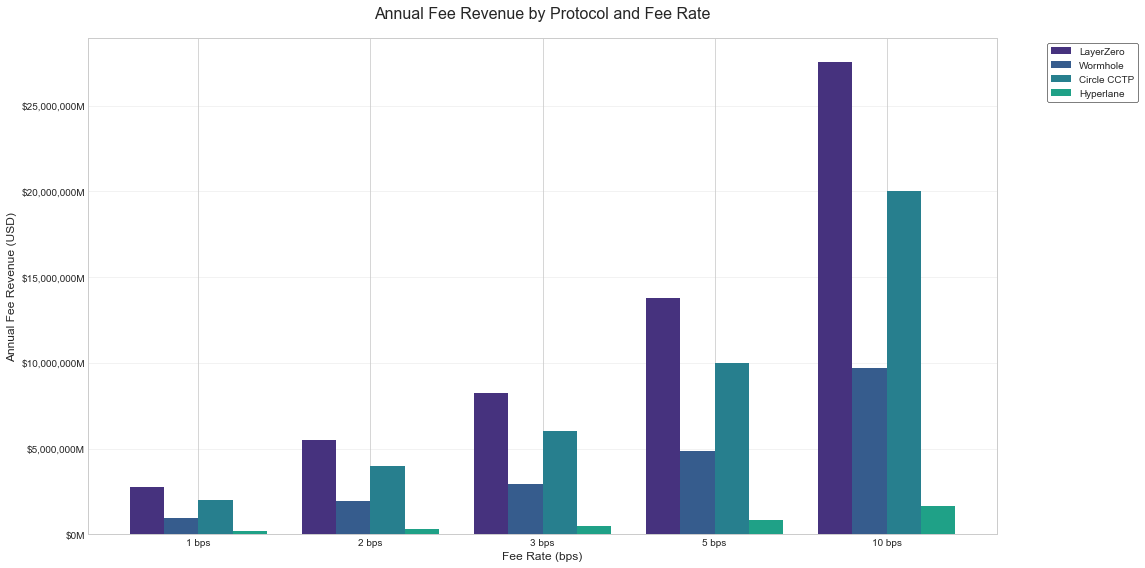

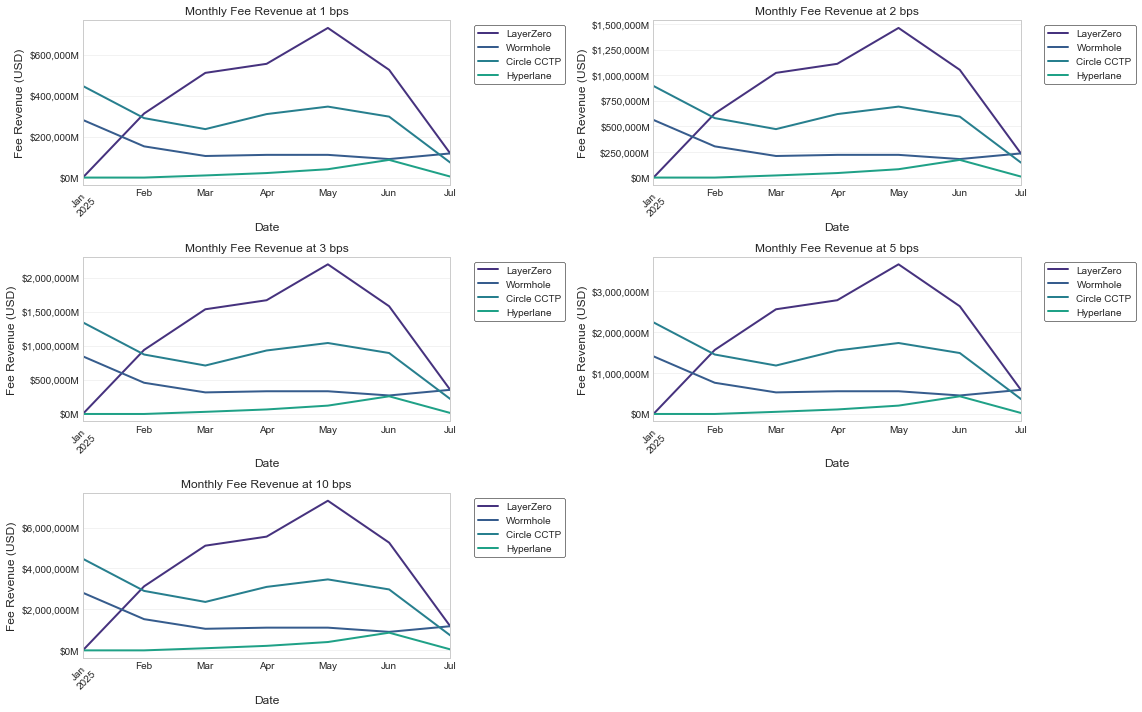

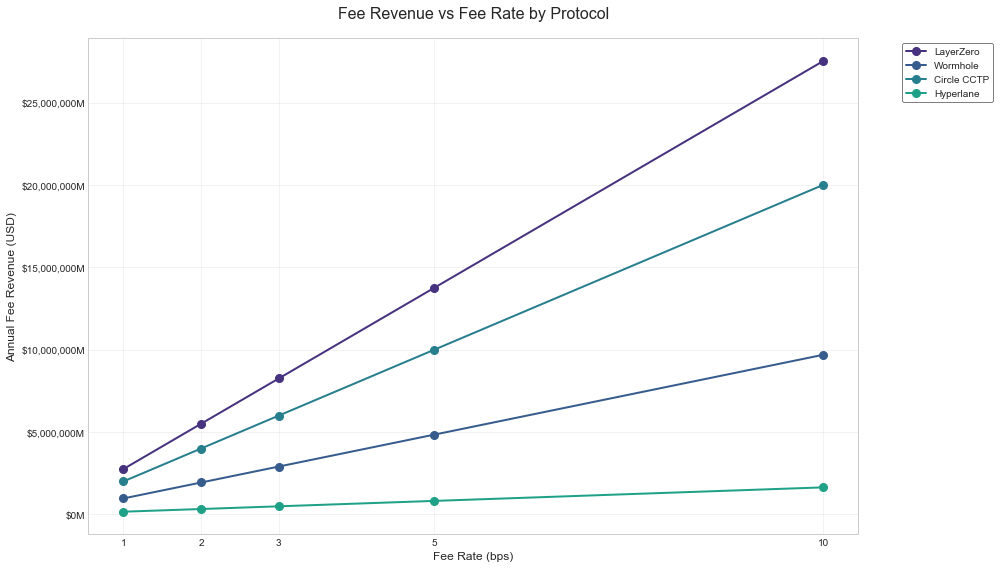


Annual Fee Revenue Comparison (in USD)


,Fee Rate,LayerZero,Wormhole,Circle CCTP,Hyperlane,Total
0,1 bps,"$2,754,050.90","$969,706.32","$2,001,831.29","$164,300.00","$5,889,888.52"
1,2 bps,"$5,508,101.81","$1,939,412.64","$4,003,662.59","$328,600.00","$11,779,777.03"
2,3 bps,"$8,262,152.71","$2,909,118.96","$6,005,493.88","$492,900.00","$17,669,665.55"
3,5 bps,"$13,770,254.51","$4,848,531.60","$10,009,156.47","$821,500.00","$29,449,442.59"
4,10 bps,"$27,540,509.03","$9,697,063.20","$20,018,312.94","$1,643,000.01","$58,898,885.17"


In [40]:
# Define the basis points for fee calculation
bps_rates = [1, 2, 3, 5, 10]  # 1 bps = 0.01%

# Function to calculate fees
def calculate_fees(volume, bps):
    return volume * (bps / 10_000)

# Calculate daily fees for each protocol
for protocol in protocols:
    for bps in bps_rates:
        result_df[f'{protocol}_{bps}bps'] = calculate_fees(result_df[protocol], bps)

# 1. Monthly Fee Revenue Analysis
monthly_fees = result_df.set_index('Date').resample('M').sum()

# Create a summary table of monthly fees
fee_columns = [f'{p}_{bps}bps' for p in protocols for bps in bps_rates]
monthly_fee_summary = monthly_fees[fee_columns]

# Calculate annual totals
annual_fees = monthly_fee_summary.sum()

# Create a summary DataFrame
fee_summary = pd.DataFrame()
for protocol in protocols:
    protocol_data = {}
    for bps in bps_rates:
        col = f'{protocol}_{bps}bps'
        total_fee = annual_fees[col]
        protocol_data[f'{bps} bps'] = f'${total_fee:,.2f}'
    fee_summary[protocol] = pd.Series(protocol_data)

# Display the fee summary
print("Annual Fee Revenue by Protocol (in USD)")
print("="*80)
display(fee_summary)

# 2. Fee Revenue Visualization
plt.figure(figsize=(16, 8))
bar_width = 0.2
index = np.arange(len(bps_rates))

for i, protocol in enumerate(protocols):
    protocol_fees = [annual_fees[f'{protocol}_{bps}bps'] for bps in bps_rates]
    plt.bar(index + i*bar_width, protocol_fees, bar_width, label=protocol)

plt.xlabel('Fee Rate (bps)', fontsize=12)
plt.ylabel('Annual Fee Revenue (USD)', fontsize=12)
plt.title('Annual Fee Revenue by Protocol and Fee Rate', fontsize=16, pad=20)
plt.xticks(index + bar_width*1.5, [f'{bps} bps' for bps in bps_rates])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, framealpha=1, edgecolor='black')
plt.grid(axis='y', alpha=0.3)

# Format y-axis in millions
formatter = FuncFormatter(millions)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.savefig('annual_fee_revenue_by_protocol.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 3. Monthly Fee Revenue Trends
plt.figure(figsize=(16, 10))
for i, bps in enumerate(bps_rates):
    plt.subplot(3, 2, i+1)
    for protocol in protocols:
        monthly_fees[f'{protocol}_{bps}bps'].plot(label=protocol, linewidth=2)
    
    plt.title(f'Monthly Fee Revenue at {bps} bps', fontsize=12)
    plt.ylabel('Fee Revenue (USD)')
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, framealpha=1, edgecolor='black')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('monthly_fee_trends_by_bps.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 4. Fee Revenue Distribution
plt.figure(figsize=(14, 8))
for protocol in protocols:
    protocol_data = [annual_fees[f'{protocol}_{bps}bps'] for bps in bps_rates]
    plt.plot(bps_rates, protocol_data, 'o-', label=protocol, markersize=8, linewidth=2)

plt.xlabel('Fee Rate (bps)', fontsize=12)
plt.ylabel('Annual Fee Revenue (USD)', fontsize=12)
plt.title('Fee Revenue vs Fee Rate by Protocol', fontsize=16, pad=20)
plt.xticks(bps_rates)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, framealpha=1, edgecolor='black')
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.savefig('fee_revenue_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 5. Fee Revenue Comparison Table
print("\nAnnual Fee Revenue Comparison (in USD)")
print("="*80)

# Create a detailed comparison table
comparison_data = []
for bps in bps_rates:
    row = {'Fee Rate': f'{bps} bps'}
    total = 0
    for protocol in protocols:
        fee = annual_fees[f'{protocol}_{bps}bps']
        row[protocol] = f'${fee:,.2f}'
        total += fee
    row['Total'] = f'${total:,.2f}'
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

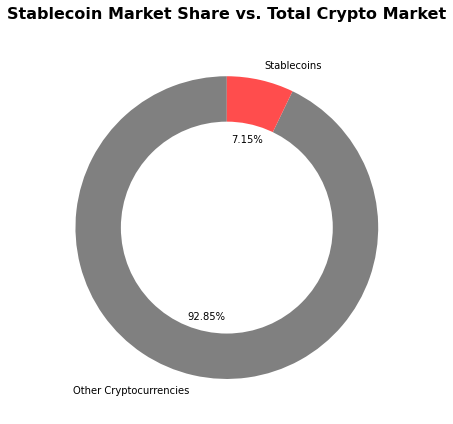

In [8]:
# Data - reversed order
labels = ['Other Cryptocurrencies', 'Stablecoins']
sizes = [3398479642209, 261520357791]  # Reversed order
colors = ['#808080','#ff4d4d']  # Also reversed to match new order

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,  # Changed from 90 to 0 to start from right
    colors=colors,
    wedgeprops={'width': 0.4}
)

# Rest of the code remains the same
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

plt.title("Stablecoin Market Share vs. Total Crypto Market", fontsize=16, fontweight='bold', pad=20)
plt.savefig('stablecoin_market_share.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()